# Question Classification with Sentence Embeddings — Codex-Style Embedding Model Comparison

1. Build a fixed train / test / holdout setup  
2. Embed each question into a feature vector  
3. Learn the same kind of linear multiclass PyTorch model on top of each embedding space  
4. Compare the two embedding models head-to-head  
5. Identify where each embedding succeeds, where it fails, and which classes each model struggles with  
6. Use confusion matrices, disagreement examples, and coarse-category analysis to diagnose model deficiencies



In [68]:
!pip install -q sentence-transformers torch scikit-learn pandas numpy matplotlib seaborn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [69]:
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


## Step 1: Load and inspect the data

In [70]:
train_df = pd.read_csv('question_classificatrion/question_classification_dataset/train.csv')
test_df = pd.read_csv('question_classificatrion/question_classification_dataset/test.csv')

print("Provided train shape:", train_df.shape)
print("Provided test shape:", test_df.shape)
display(train_df.head())

print("\nNumber of coarse labels:", train_df["label-coarse"].nunique())
print("Number of fine labels:", train_df["label-fine"].nunique())

Provided train shape: (5452, 3)
Provided test shape: (500, 3)


,label-coarse,label-fine,text
0,0,0,How did serfdom develop in and then leave Russ...
1,1,1,What films featured the character Popeye Doyle ?
2,0,0,How can I find a list of celebrities ' real na...
3,1,2,What fowl grabs the spotlight after the Chines...
4,2,3,What is the full form of .com ?



Number of coarse labels: 6
Number of fine labels: 47


## Step 2: Recombine and create one fixed random 60 / 20 / 20 split

Instead, we keep one fixed **60% train / 20% test / 20% holdout** split 


In [71]:
full_df = pd.concat([train_df, test_df], ignore_index=True).reset_index(drop=True)
print("Combined shape:", full_df.shape)

focused_df = full_df.copy()

train_test_df, holdout_df = train_test_split(
    focused_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=focused_df["label-fine"]
)

train_split_df, test_split_df = train_test_split(
    train_test_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_test_df["label-fine"]
)

print("Train shape:", train_split_df.shape)
print("Test shape:", test_split_df.shape)
print("Holdout shape:", holdout_df.shape)

print("\nTrain fine-label distribution:")
display(train_split_df["label-fine"].value_counts().sort_index())

print("\nTest fine-label distribution:")
display(test_split_df["label-fine"].value_counts().sort_index())

print("\nHoldout fine-label distribution:")
display(holdout_df["label-fine"].value_counts().sort_index())


Combined shape: (5952, 3)
Train shape: (3808, 3)
Test shape: (953, 3)
Holdout shape: (1191, 3)

Train fine-label distribution:


label-fine
0     177
1     133
2      82
3      50
4     651
5     125
6      17
7     348
8     169
9     126
10     37
11     46
12    212
13    238
14    517
15      6
16      2
17     69
18    101
19     32
20     64
21     94
22     11
23     67
24     15
25     47
26     30
27     53
28     36
29     40
30     11
31     25
32      8
33      7
34     11
35     10
36     17
37     11
38     19
39      6
40     32
41      9
42      7
43      4
44     20
45     10
46      6
Name: count, dtype: int64


Test fine-label distribution:


label-fine
0      45
1      33
2      20
3      12
4     163
5      31
6       4
7      87
8      43
9      32
10      9
11     12
12     53
13     60
14    129
15      1
16      1
17     17
18     25
19      8
20     16
21     24
22      3
23     17
24      4
25     12
26      7
27     13
28      9
29     10
30      3
31      6
32      2
33      2
34      3
35      2
36      4
37      3
38      5
39      1
40      8
41      2
42      2
43      1
44      5
45      2
46      2
Name: count, dtype: int64


Holdout fine-label distribution:


label-fine
0      56
1      41
2      26
3      16
4     203
5      39
6       5
7     109
8      53
9      39
10     12
11     15
12     66
13     74
14    161
15      2
16      1
17     21
18     32
19     10
20     20
21     29
22      4
23     21
24      5
25     15
26      9
27     17
28     11
29     13
30      4
31      8
32      3
33      2
34      3
35      3
36      5
37      4
38      6
39      2
40     10
41      2
42      2
43      1
44      6
45      3
46      2
Name: count, dtype: int64

## Step 3: Choose two embedding models

We still use sentence embeddings, but now the embedding becomes the **input vector** `x in R^d` for the linear supervised learner.


In [72]:
embedding_models = [
    "all-MiniLM-L6-v2",
    "paraphrase-MiniLM-L6-v2",
]

X_train_text = train_split_df["text"].tolist()
X_test_text = test_split_df["text"].tolist()
X_holdout_text = holdout_df["text"].tolist()

y_train_labels = train_split_df["label-fine"].to_numpy()
y_test_labels = test_split_df["label-fine"].to_numpy()
y_holdout_labels = holdout_df["label-fine"].to_numpy()

y_test_coarse = test_split_df["label-coarse"].to_numpy()
y_holdout_coarse = holdout_df["label-coarse"].to_numpy()

class_names = sorted(focused_df["label-fine"].unique().tolist())
class_to_idx = {label: idx for idx, label in enumerate(class_names)}
idx_to_class = {idx: label for label, idx in class_to_idx.items()}

class_names_coarse = sorted(focused_df["label-coarse"].unique().tolist())
fine_to_coarse = (
    focused_df[["label-fine", "label-coarse"]]
    .drop_duplicates()
    .set_index("label-fine")["label-coarse"]
    .to_dict()
)

print("Fine classes:", class_names)
print("Number of fine classes:", len(class_names))
print("Coarse classes:", class_names_coarse)
print("Number of coarse classes:", len(class_names_coarse))


Fine classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]
Number of fine classes: 47
Coarse classes: [0, 1, 2, 3, 4, 5]
Number of coarse classes: 6


## Helper functions


In [73]:
def embed_texts(model_name, texts):
    # Load the sentence-transformer model and encode the input texts.
    model = SentenceTransformer(model_name)
    # Encode all texts into a 2D numpy array of embeddings.
    embeddings = model.encode(texts, convert_to_numpy=True, show_progress_bar=False)
    return embeddings


def labels_to_index(labels, class_to_idx):
    # Map each label string to its integer class index.
    return np.array([class_to_idx[label] for label in labels], dtype=np.int64)


def one_hot_encode(label_indices, num_classes):
    # Build one-hot rows for each class index.
    return np.eye(num_classes, dtype=np.float32)[label_indices]


def make_multiclass_tensors(X_np, y_labels, class_to_idx):
    # Convert labels to indices and one-hot encode them for training.
    y_idx = labels_to_index(y_labels, class_to_idx)
    y_onehot = one_hot_encode(y_idx, len(class_to_idx))

    # Convert embeddings and one-hot labels into float tensors.
    X_tensor = torch.tensor(X_np, dtype=torch.float32).reshape(X_np.shape)
    Y_onehot_tensor = torch.tensor(y_onehot, dtype=torch.float32).reshape(y_onehot.shape)

    # Return tensors plus raw class indices for metrics.
    return X_tensor, Y_onehot_tensor, y_idx


def model_fit_pytorch(x_train, y_train, model, loss_criterion=None, epochs=1000, lr=0.01):
    # Default to MSE loss for one-hot regression-style training.
    if loss_criterion is None:
        loss_criterion = nn.MSELoss()
    # Use simple SGD for optimization.
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # Track training loss over epochs for plotting.
    loss_history = []

    # Standard training loop: forward, loss, backward, step.
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Forward pass and loss computation.
        y_pred = model(x_train)
        loss = loss_criterion(y_pred, y_train)

        # Backpropagation and parameter update.
        loss.backward()
        optimizer.step()

        # Store loss for later visualization.
        loss_history.append(loss.item())

    return model, loss_history


def pytorch_model_multiclass_inference(model, X_tensor):
    # Run the model in eval mode and return scores plus class indices.
    model.eval()
    with torch.no_grad():
        # Raw model outputs for each class.
        Y_pred = model(X_tensor)
        # Take argmax to get predicted class index.
        pred_idx = torch.argmax(Y_pred, dim=1).detach().cpu().numpy()
    return Y_pred.detach().cpu().numpy(), pred_idx



def plot_conf_mat(y_true, y_pred, labels, title, save_path=None):
    # Compute a row-normalized confusion matrix in percent.
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true") * 100

    # Create a heatmap-style plot.
    fig, ax = plt.subplots(figsize=(max(7, 0.6 * len(labels)), max(6, 0.55 * len(labels))))
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=100)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Label axes with class names.
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # Annotate each cell with its percentage.
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{cm[i, j]:.1f}", ha="center", va="center", color="black")

    # Add labels, title, and gridlines for readability.
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True (row %)")
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xticks(np.arange(len(labels) + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(labels) + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    plt.tight_layout()

    # Optionally save the figure to disk.
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()


def build_linear_multiclass_model(input_dim, output_dim):
    # Create a single-layer linear classifier for multiclass prediction.
    return nn.Sequential(nn.Linear(input_dim, output_dim))


def train_one_embedding_pipeline(model_name, X_train_text, X_test_text, X_holdout_text, y_train_labels, y_test_labels, y_holdout_labels, class_to_idx, class_names, epochs=2000, lr=0.02):
    # End-to-end pipeline: embed text, train classifier, and collect predictions.
    print(f"===== Running {model_name} =====")

    # Generate embeddings for each data split.
    X_train_emb = embed_texts(model_name, X_train_text)
    X_test_emb = embed_texts(model_name, X_test_text)
    X_holdout_emb = embed_texts(model_name, X_holdout_text)

    # Convert embeddings/labels into PyTorch tensors.
    X_train_tensor, Y_train_onehot_tensor, _ = make_multiclass_tensors(X_train_emb, y_train_labels, class_to_idx)
    X_test_tensor, _, y_test_idx = make_multiclass_tensors(X_test_emb, y_test_labels, class_to_idx)
    X_holdout_tensor, _, y_holdout_idx = make_multiclass_tensors(X_holdout_emb, y_holdout_labels, class_to_idx)

    # Build a linear classifier sized to the embedding dimension.
    linear_model = build_linear_multiclass_model(
        input_dim=X_train_tensor.shape[1],
        output_dim=Y_train_onehot_tensor.shape[1]
    )

    # Train the model on the training split.
    trained_model, loss_history = model_fit_pytorch(
        X_train_tensor,
        Y_train_onehot_tensor,
        linear_model,
        epochs=epochs,
        lr=lr
    )

    # Predict fine labels on the test split.
    _, test_pred_idx = pytorch_model_multiclass_inference(trained_model, X_test_tensor)
    test_pred_labels = np.array([class_names[i] for i in test_pred_idx], dtype=object)

    # Predict fine labels on the holdout split.
    _, holdout_pred_idx = pytorch_model_multiclass_inference(trained_model, X_holdout_tensor)
    holdout_pred_labels = np.array([class_names[i] for i in holdout_pred_idx], dtype=object)

    # Collect outputs for later evaluation and plotting.
    artifacts = {
        "model_name": model_name,
        "trained_model": trained_model,
        "loss_history": loss_history,
        "y_test_idx": y_test_idx,
        "test_pred_idx": test_pred_idx,
        "test_pred_labels": test_pred_labels,
        "y_holdout_idx": y_holdout_idx,
        "holdout_pred_idx": holdout_pred_idx,
        "holdout_pred_labels": holdout_pred_labels,
    }
    return artifacts


## Step 4: Embed the data and train the linear multiclass PyTorch model


In [ ]:
artifacts = {}

for model_name in embedding_models:
    run_artifacts = train_one_embedding_pipeline(
        model_name=model_name,
        X_train_text=X_train_text,
        X_test_text=X_test_text,
        X_holdout_text=X_holdout_text,
        y_train_labels=y_train_labels,
        y_test_labels=y_test_labels,
        y_holdout_labels=y_holdout_labels,
        class_to_idx=class_to_idx,
        class_names=class_names,
        epochs=100000,
        lr=0.05,
    )
    artifacts[model_name] = run_artifacts


===== Running all-MiniLM-L6-v2 =====


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


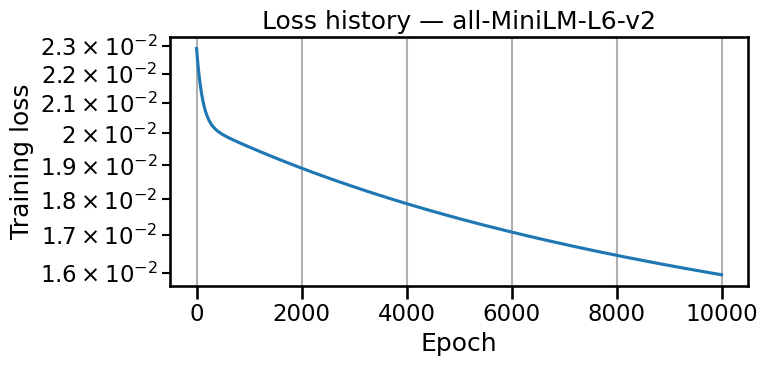

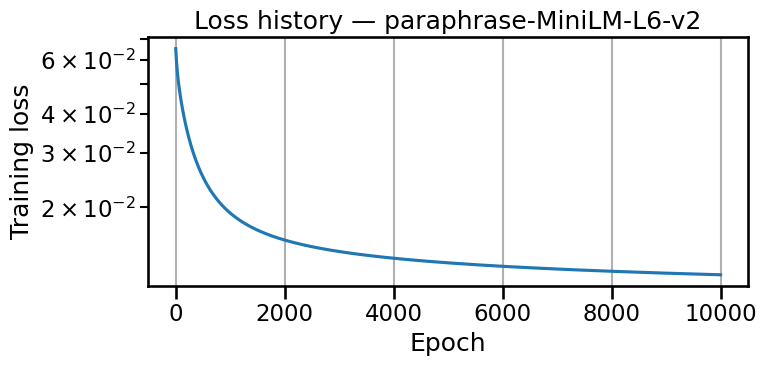

In [75]:
# Plot training loss history (log scale) for each embedding model
for model_name in embedding_models:
    loss_history = artifacts[model_name]["loss_history"]
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(len(loss_history)), loss_history)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title(f"Loss history — {model_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Step 5: Baseline head-to-head comparison

Now that both embedding models have been trained using the same linear PyTorch classifier pipeline, we compare them in several ways:

- overall metrics on train / test / holdout
- fine-label confusion matrices
- per-class F1 differences
- disagreement examples on the same test questions

This lets us separate **overall performance** from **where each embedding succeeds or fails**.


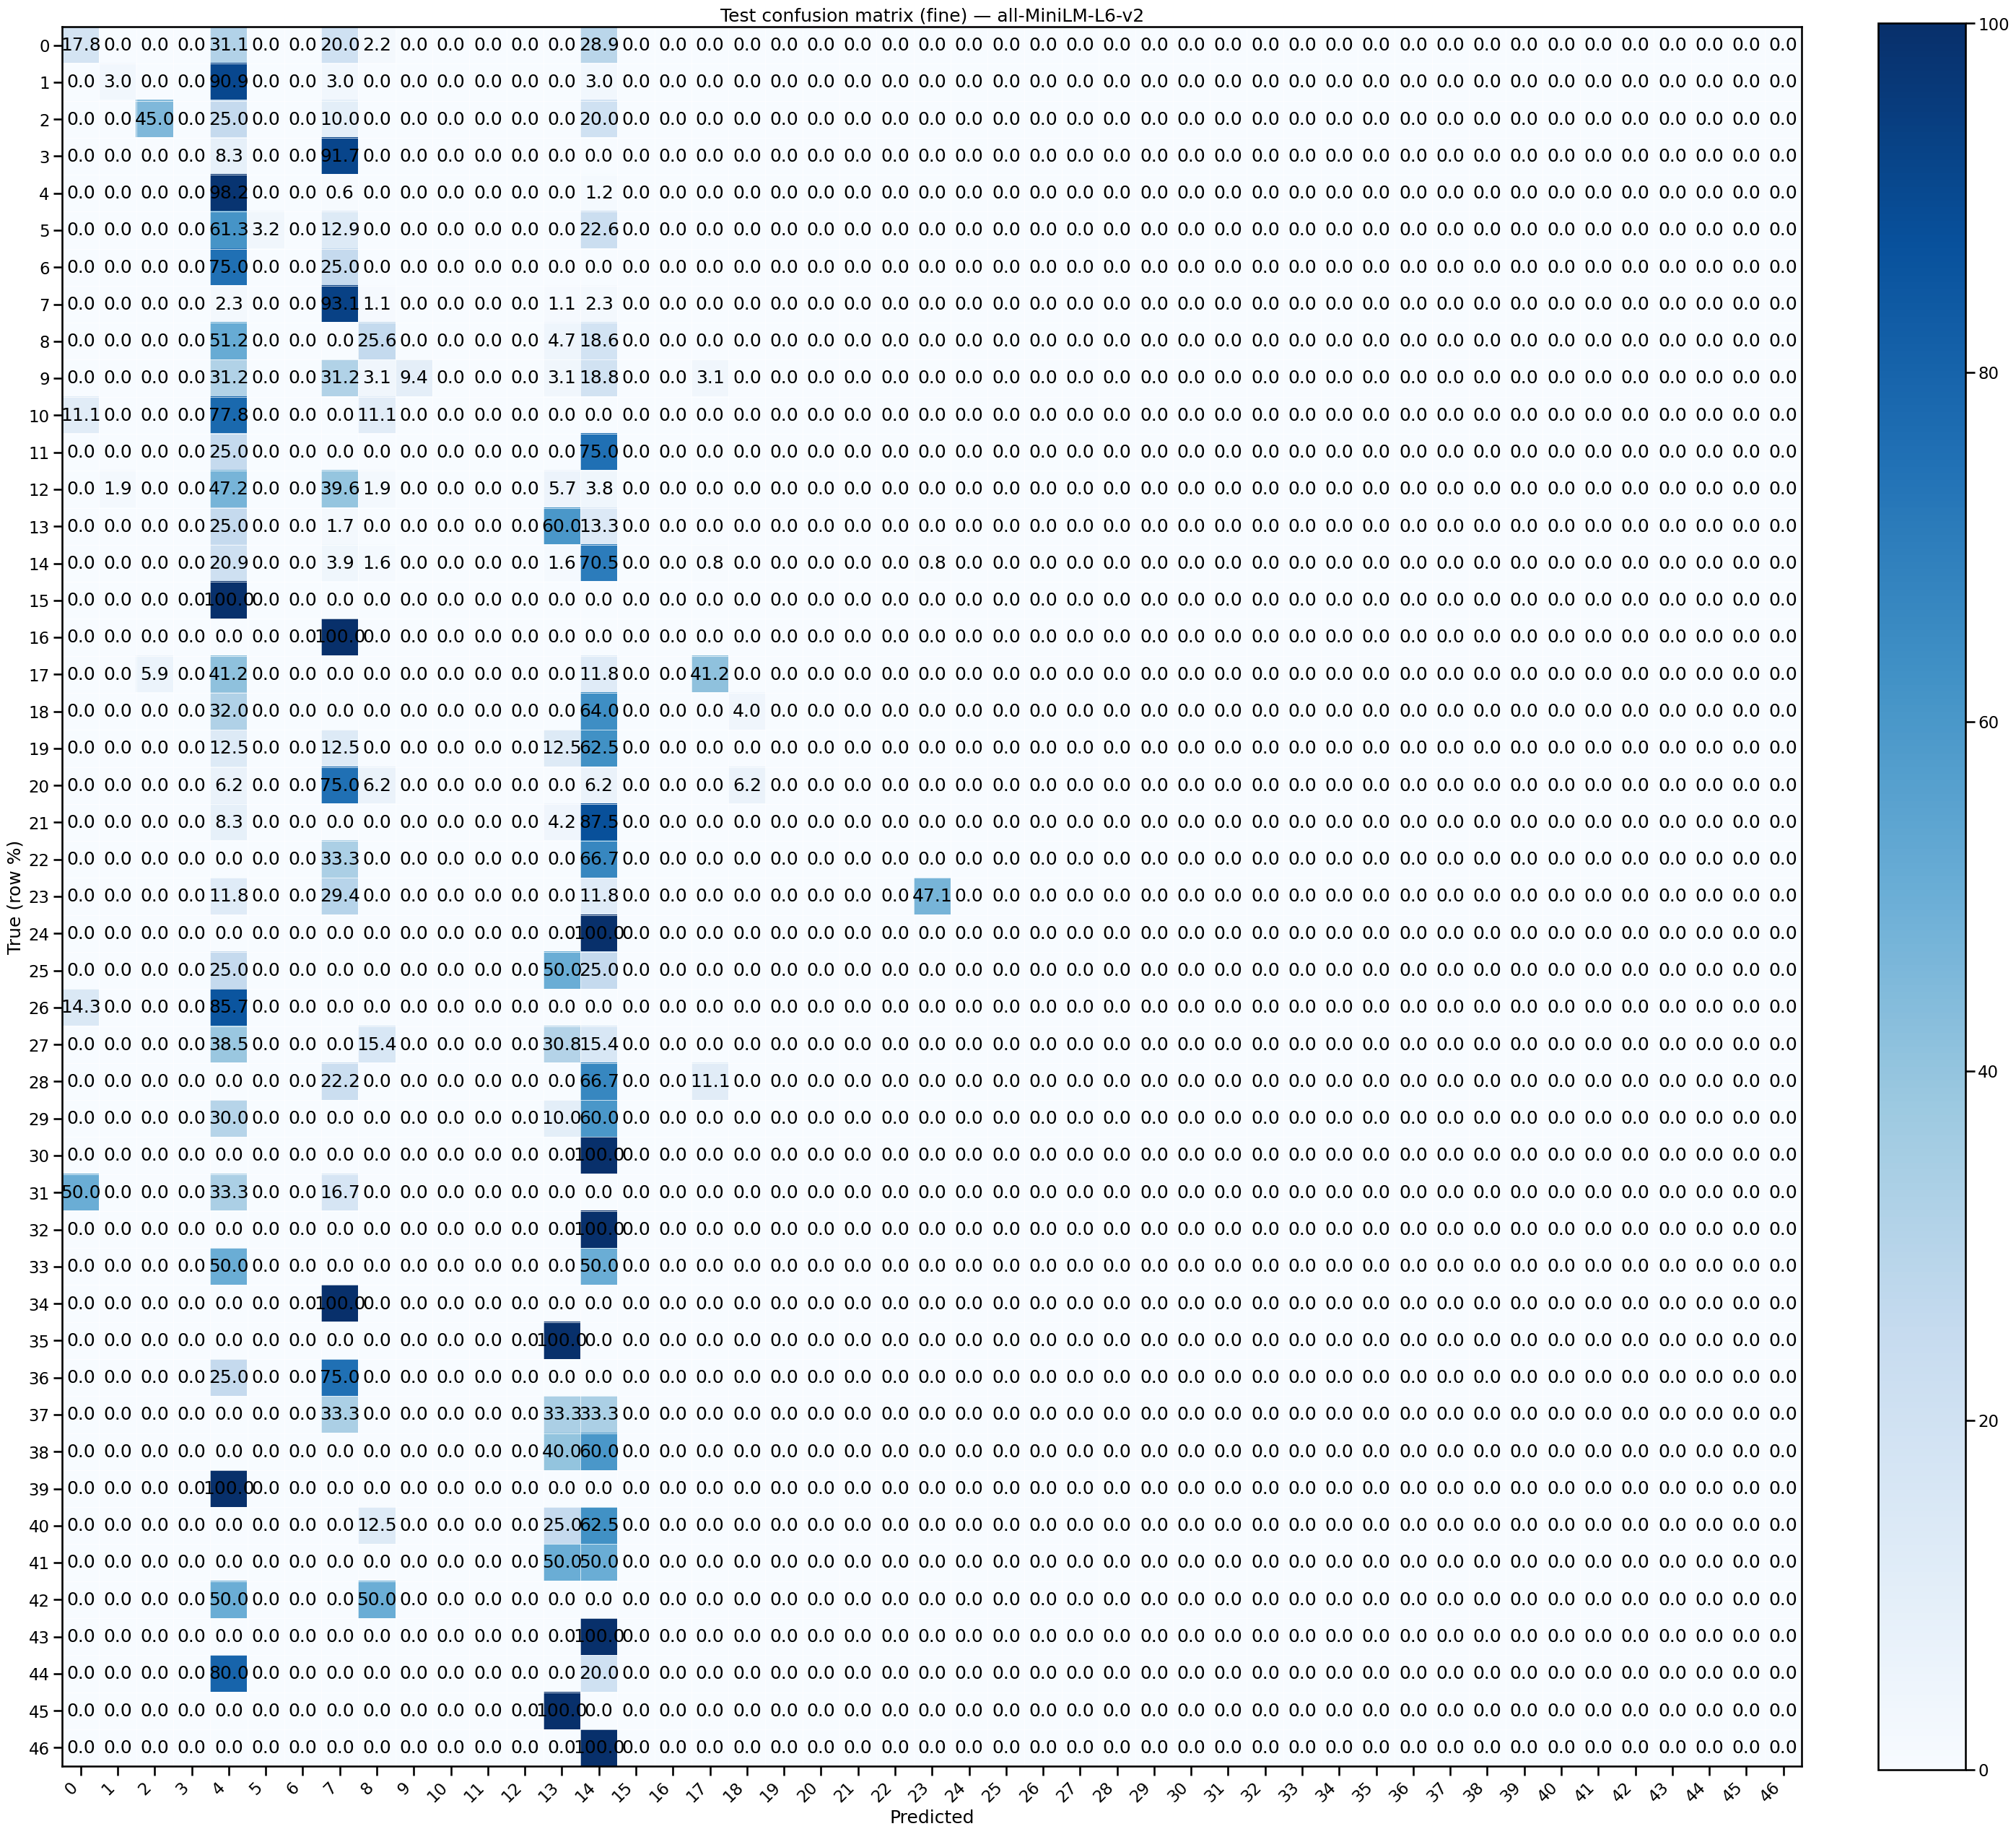

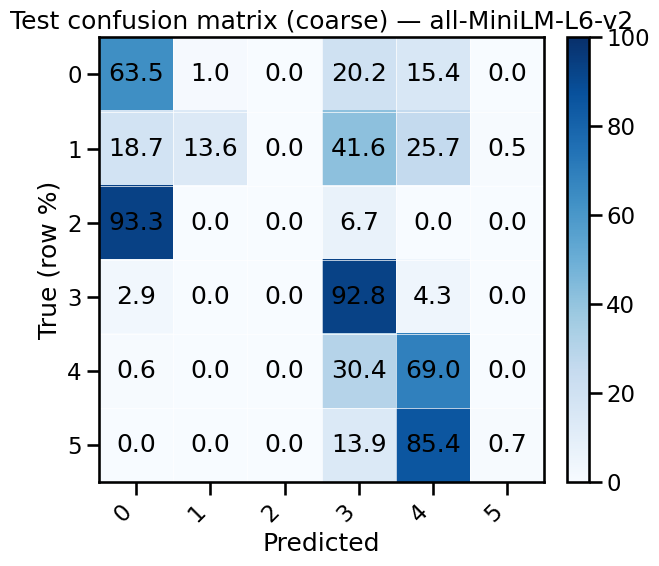

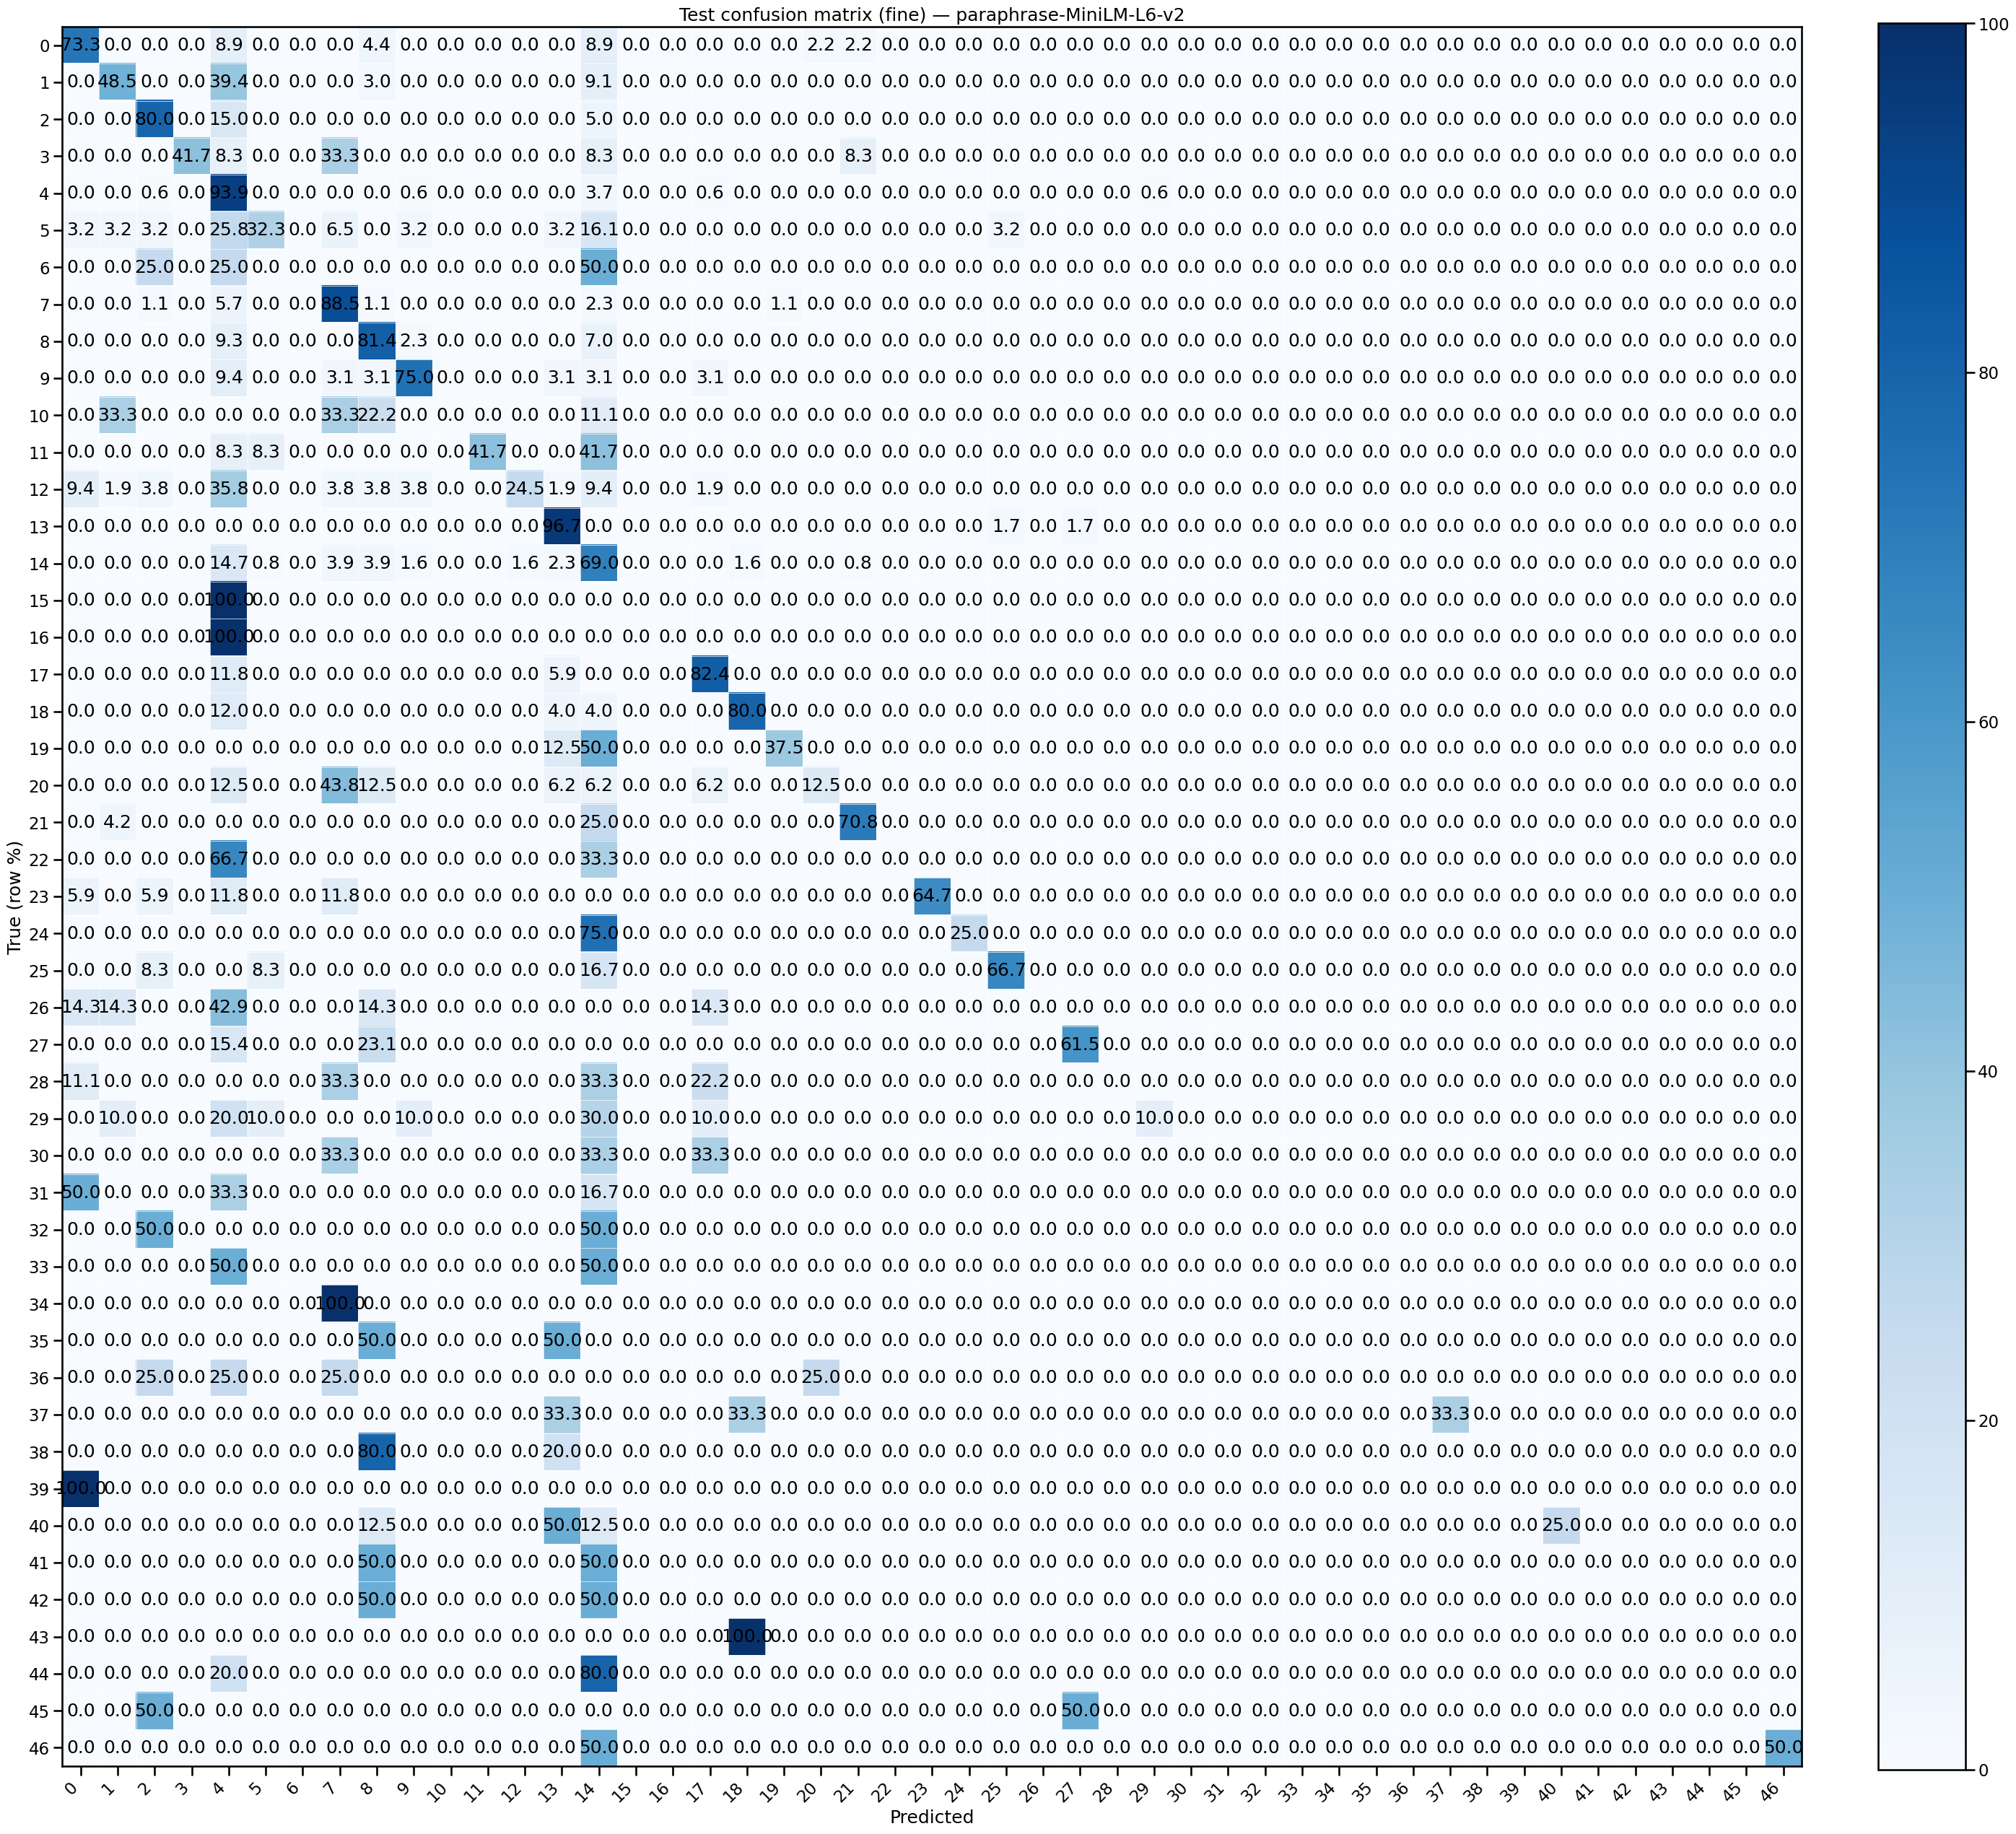

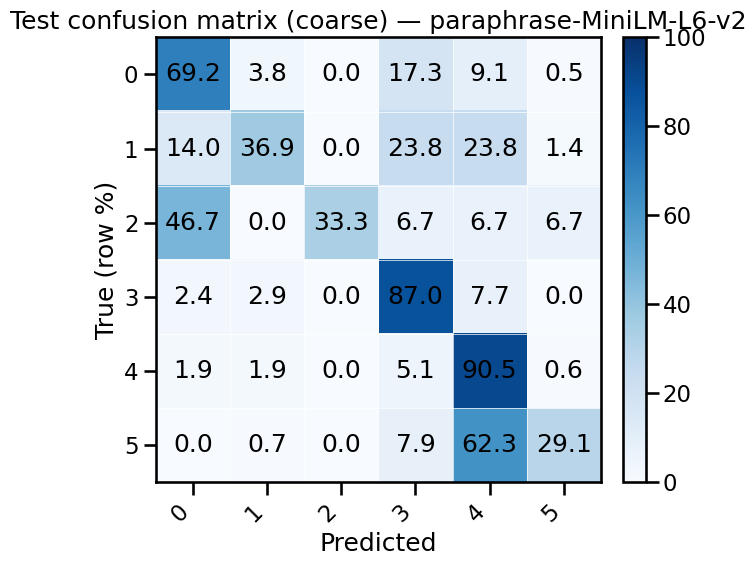

In [76]:
matrices_dir = Path("matrices")

for model_name in embedding_models:
    plot_conf_mat(
        artifacts[model_name]["y_test_idx"],
        artifacts[model_name]["test_pred_idx"],
        labels=np.arange(len(class_names)),
        title=f"Test confusion matrix (fine) — {model_name}",
        save_path=matrices_dir / f"baseline_{model_name}_fine.png"
    )

    # coarse view: map predicted fine label -> coarse label
    test_pred_coarse = pd.Series(artifacts[model_name]["test_pred_labels"]).map(fine_to_coarse).to_numpy()

    plot_conf_mat(
        y_test_coarse,
        test_pred_coarse,
        labels=class_names_coarse,
        title=f"Test confusion matrix (coarse) — {model_name}",
        save_path=matrices_dir / f"baseline_{model_name}_coarse.png"
    )

In [77]:
# Download All matrices
from pathlib import Path
import shutil

src_dir = Path('matrices')
dst_dir = Path('new_matrices')
dst_dir.mkdir(parents=True, exist_ok=True)

# newCodeBase writes baseline_{model}_fine/coarse.png -> 4 files total
patterns = ["baseline_*_fine.png", "baseline_*_coarse.png"]
copied = 0
for pattern in patterns:
    for img_path in src_dir.glob(pattern):
        shutil.copy2(img_path, dst_dir / img_path.name)
        copied += 1

print(f'Copied {copied} files to {dst_dir}')


Copied 4 files to new_matrices


In [78]:
# Combine the 4 matrices into a single PDF
from pathlib import Path
from PIL import Image

src_dir = Path('new_matrices')
pdf_path = src_dir / 'combined_matrices.pdf'

image_paths = sorted(src_dir.glob('baseline_*_*.png'))
if not image_paths:
    raise FileNotFoundError('No matrices found in new_matrices')

images = [Image.open(p).convert('RGB') for p in image_paths]
images[0].save(pdf_path, save_all=True, append_images=images[1:])

print(f'Wrote {pdf_path} with {len(images)} pages')


Wrote new_matrices/combined_matrices.pdf with 4 pages
